# Какой маршрут быстрее: №118 или №169?
## Моссовет → Азия Молл. Практикум после занятия 8 · KEY

Сравним время в пути и ответим на три вопроса:

1. Какой маршрут в среднем быстрее утром?
2. Как часто такая разница получается при случайном обмене названий маршрутов?
3. Насколько точно мы оценили среднюю разницу?

Используем знакомые данные и два метода: **перестановки** и **бутстрап**.
Ожидание автобуса не учитываем. Работа рассчитана на одно занятие после запуска подготовки данных.

**Как работать.** Сначала запустите часть 0 — она целиком скопирована из предыдущего практикума.
Затем переходите к **части 1**. В подготовке данных ничего дописывать не нужно.

В этой преподавательской версии решения уже есть. Студентам предстоит написать только короткие
фрагменты **A–D**. Код подготовки таблиц и графиков останется готовым.

Загрузка прежняя: если готового архива нет, ноутбук сам скачает данные с HF и соберёт его.
Упоминания старых заданий внутри части 0 относятся к предыдущему практикуму.

## Зависимости для локального запуска (раздел свёрнут)

В Google Colab ничего устанавливать не нужно: все библиотеки уже есть.

Для запуска на своём компьютере нужны Python 3.10 или новее и библиотеки:

```
pip install numpy pandas pyarrow matplotlib scipy huggingface_hub
```

- **Версии.** Проверено с pandas 2.2 и 3.0, numpy 2.0 и новее, matplotlib 3.10–3.11, scipy 1.14–1.18. Скорее всего, подойдут и более ранние версии, но нужны как минимум pandas 2.0 и matplotlib 3.6.
- **Интернет.** Нужен доступ к huggingface.co: ноутбук скачивает готовую выгрузку данных, около 21 МБ.
- **Запасной путь.** Если выгрузка недоступна, ноутбук соберёт её сам из исходной ленты датасета. Это около 3,7 ГБ скачивания и несколько минут работы. Результат сохранится рядом с ноутбуком в файле `mossovet_asia_mall_2026.zip`, и следующий запуск будет быстрым.
- **Архив в той же папке.** Если положить `mossovet_asia_mall_2026.zip` рядом с ноутбуком заранее, скачивание не понадобится.

# Часть 0. От сырой ленты к таблице поездок

Сырые данные — это не поездки, а отметки: каждые ~5 секунд лента сообщает, где находится каждый автобус. Чтобы получить время в пути, нужно:

1. загрузить отметки маршрутов №118 и №169 в районе между остановками;
2. убрать повторяющиеся отметки;
3. перевести координаты в метры;
4. составить из соседних отметок шаги-векторы;
5. найти моменты, когда автобус проезжал нужные остановки;
6. собрать поездки от A до B и проверить, что автобус ехал своим путём;
7. добавить календарь и проверить, насколько полны данные за каждый день.

### 0.1 Библиотеки и настройки

In [1]:
# Standard scientific stack; everything is preinstalled in Google Colab
import io
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)

TZ = 'Asia/Bishkek'                        # local time, UTC+6 all year round
COLORS = {118: '#2a78d6', 169: '#eb6834'}  # one colour per route in every chart
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': '#c3c2b7',
})

### 0.2 Загрузка данных

Исходный датасет большой: 372 млн строк за два месяца по всему городу. Для практикума заранее сделана выгрузка на 21 МБ. В неё вошли:

- `positions` — все строки ленты по автобусам №118 и №169 внутри прямоугольника вокруг обоих путей (около 3,3 × 2,9 км), местные даты 25.07–22.09.2026. Повторяющиеся строки оставлены намеренно: их уберём сами;
- `feed_gaps` — перерывы больше 2 минут, когда лента не записывалась вообще (по всем автобусам города);
- `streets` — отметки всех маршрутов в том же прямоугольнике за один будний день. Они служат фоном для карт: показывают улицы, по которым ходит транспорт;
- `stops` — справочник всех 1 501 остановки Бишкека.

Код выгрузки приведён в ячейке ниже: `build_extract` просто фильтрует исходные файлы ленты по номеру маршрута, типу транспорта (2 = автобус) и прямоугольнику. Если готовой выгрузки нет, ноутбук выполнит эту же функцию на исходных файлах.

In [2]:
# Where the data come from
REPO_ID = 'aiacademy-kg/bishkek-transport'             # the open dataset on Hugging Face
REVISION = '4aa20aab0b17f10b66af45a9ea04e4d5e61a9f6f'  # fixed snapshot of the dataset (23.09.2026)
EXTRACT_NAME = 'mossovet_asia_mall_2026.zip'           # the prepared extract, ~21 MB
EXTRACT_IN_REPO = 'practicum/' + EXTRACT_NAME          # its place in the dataset repository

# Extract builder: the same code produced the prepared zip
ROUTES = (118, 169)
VEHICLE_TYPE = 2                                             # 2 = bus
BBOX = {'lat': (42.850, 42.876), 'lng': (74.579, 74.619)}    # both paths plus ~600 m around
PERIOD_UTC = ('2026-07-24T18:00:00+00:00', '2026-09-22T18:00:00+00:00')  # local dates 25.07-22.09
GAP_S = 120                                                  # a longer pause between polls is a gap
STREETS_FILE = 'transport-20260916T071530Z.parquet'          # Wed 16.09.2026, 13:15-18:00 local
TABLES = ['positions', 'feed_gaps', 'streets', 'stops']


def build_extract(feed_files, stops_path):
    """Filter the raw feed files (tracking/*.parquet, in time order); returns a dict of DataFrames."""
    parts, polls, streets = [], [], None
    for path in feed_files:
        d = pd.read_parquet(path, columns=['ts', 'id', 'type', 'route', 'lat', 'lng'])
        polls.append(d['ts'].drop_duplicates())      # poll times of the whole city, to find gaps
        in_box = d['lat'].between(*BBOX['lat']) & d['lng'].between(*BBOX['lng'])
        ours = d['type'].eq(VEHICLE_TYPE) & d['route'].isin(ROUTES) & in_box
        parts.append(d.loc[ours, ['ts', 'id', 'route', 'lat', 'lng']])
        if Path(path).name == STREETS_FILE:          # all transit in the box: streets for the maps
            streets = (d.loc[in_box, ['lat', 'lng']].round(4).drop_duplicates()
                       .sort_values(['lat', 'lng']).reset_index(drop=True))

    positions = pd.concat(parts, ignore_index=True)
    t = pd.to_datetime(positions['ts'], format='ISO8601', utc=True)
    period = (t >= pd.Timestamp(PERIOD_UTC[0])) & (t < pd.Timestamp(PERIOD_UTC[1]))
    positions = positions[period].astype({'id': 'int32', 'route': 'int16'}).reset_index(drop=True)

    poll = pd.to_datetime(pd.concat(polls).drop_duplicates(), format='ISO8601', utc=True)
    poll = poll.sort_values().reset_index(drop=True)
    pause = poll.diff().dt.total_seconds()
    i = pause.index[pause > GAP_S]
    gaps = pd.DataFrame({'gap_start_utc': poll[i - 1].to_numpy(), 'gap_end_utc': poll[i].to_numpy()})
    in_period = (gaps['gap_end_utc'] > pd.Timestamp(PERIOD_UTC[0])) & (gaps['gap_start_utc'] < pd.Timestamp(PERIOD_UTC[1]))
    gaps = gaps[in_period].reset_index(drop=True)
    return {'positions': positions, 'feed_gaps': gaps, 'streets': streets, 'stops': pd.read_parquet(stops_path)}


def save_zip(tables, path):
    """All tables as parquet files inside one zip archive."""
    with zipfile.ZipFile(path, 'w', compression=zipfile.ZIP_STORED) as z:
        for name in TABLES:
            buffer = io.BytesIO()
            tables[name].to_parquet(buffer, index=False, compression='zstd')
            z.writestr(f'{name}.parquet', buffer.getvalue())


def load_zip(path):
    with zipfile.ZipFile(path) as z:
        return {name: pd.read_parquet(io.BytesIO(z.read(f'{name}.parquet'))) for name in TABLES}


def build_from_raw_feed():
    """Fallback: download the raw feed files of the period (~3.7 GB) and filter them."""
    from concurrent.futures import ThreadPoolExecutor
    from huggingface_hub import HfApi, hf_hub_download
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
    names = sorted(f for f in HfApi().list_repo_files(REPO_ID, repo_type='dataset', revision=REVISION)
                   if f.startswith('tracking/') and f.endswith('.parquet'))
    # A file name holds the start time of the file; keep the files that overlap the period
    starts = pd.to_datetime([Path(f).stem.split('-')[1] for f in names], format='%Y%m%dT%H%M%SZ', utc=True)
    ends = list(starts[1:]) + [pd.Timestamp('2100-01-01', tz='UTC')]
    names = [f for f, s, e in zip(names, starts, ends)
             if s < pd.Timestamp(PERIOD_UTC[1]) and e > pd.Timestamp(PERIOD_UTC[0])]
    print(f'Скачиваю {len(names)} файлов исходной ленты (~3,7 ГБ), это займёт несколько минут...')
    download = lambda name: hf_hub_download(REPO_ID, name, repo_type='dataset', revision=REVISION)
    with ThreadPoolExecutor(max_workers=8) as pool:
        paths = list(pool.map(download, names))
    stops_path = hf_hub_download(REPO_ID, 'stops/stops.parquet', repo_type='dataset', revision=REVISION)
    print('Фильтрую файлы...')
    return build_extract(paths, stops_path)


def get_tables():
    """A local zip next to the notebook -> the prepared zip from Hugging Face -> rebuild from the raw feed."""
    local = Path(EXTRACT_NAME)
    if not local.exists():
        try:
            from huggingface_hub import hf_hub_download
            local = Path(hf_hub_download(REPO_ID, EXTRACT_IN_REPO, repo_type='dataset'))
        except Exception as error:
            print('Готовая выгрузка недоступна:', type(error).__name__)
            tables = build_from_raw_feed()
            save_zip(tables, EXTRACT_NAME)  # keep it next to the notebook for the next run
            return tables
    return load_zip(local)

In [3]:
tables = get_tables()
positions_raw = tables['positions']  # raw feed rows of routes 118 and 169 in the study area
stops = tables['stops']              # all stops of Bishkek
feed_gaps = tables['feed_gaps']      # pauses in the recording of the whole feed
streets = tables['streets']          # background for the maps

# One time unit for every timestamp keeps pandas 2 and pandas 3 consistent
for col in ['gap_start_utc', 'gap_end_utc']:
    feed_gaps[col] = feed_gaps[col].dt.as_unit('ns')
print('строк ленты:', len(positions_raw), '| остановок в справочнике:', len(stops), '| перерывов записи:', len(feed_gaps))

строк ленты: 2810880 | остановок в справочнике: 1501 | перерывов записи: 27


### 0.3 Как выглядит лента

In [4]:
positions_raw.head()

,ts,id,route,lat,lng
0,2026-07-24T22:42:08.699674+00:00,1850,169,42.856964,74.610309
1,2026-07-24T22:42:14.358208+00:00,1850,169,42.856964,74.610309
2,2026-07-24T22:42:20.005169+00:00,1850,169,42.856964,74.610309
3,2026-07-24T22:42:25.668854+00:00,1850,169,42.856964,74.610309
4,2026-07-24T22:42:31.292996+00:00,1850,169,42.856950,74.610308


Что означают столбцы:

- `ts` — момент опроса ленты, **UTC**. Лента опрашивалась каждые ~5 секунд. В одном опросе ~700 машин всего города, и у всех одно и то же `ts`.
- `id` — номер машины в ленте;
- `route` — номер маршрута;
- `lat`, `lng` — широта и долгота. Их уже «прижала» к линии маршрута сама система мониторинга, поэтому это не сырые GPS-координаты, а точки на линии маршрута.

Новая отметка появляется, когда автобус сдвинулся: примерно раз в 10–20 секунд движения или через ~110 м. В остальные опросы лента повторяет прежние координаты. Посмотрим на одну машину за три минуты:

In [5]:
three_minutes = positions_raw[positions_raw['ts'].between('2026-09-16T04:00', '2026-09-16T04:03')]  # 10:00–10:03 local
bus = three_minutes['id'].iloc[0]
three_minutes[three_minutes['id'] == bus]

,ts,id,route,lat,lng
2387522,2026-09-16T04:00:02.455660+00:00,1679,118,42.866923,74.606609
2387528,2026-09-16T04:00:08.236838+00:00,1679,118,42.866943,74.606089
2387534,2026-09-16T04:00:14.126198+00:00,1679,118,42.866943,74.606089
2387540,2026-09-16T04:00:20.197748+00:00,1679,118,42.866995,74.604808
2387546,2026-09-16T04:00:25.951489+00:00,1679,118,42.866995,74.604808
2387552,2026-09-16T04:00:36.003735+00:00,1679,118,42.867044,74.603580
2387558,2026-09-16T04:00:41.716499+00:00,1679,118,42.867044,74.603580
2387564,2026-09-16T04:00:47.504947+00:00,1679,118,42.867135,74.601309
2387570,2026-09-16T04:00:53.178833+00:00,1679,118,42.867135,74.601309
2387576,2026-09-16T04:00:58.892776+00:00,1679,118,42.867135,74.601309


In [6]:
print('машин по маршрутам:', positions_raw.groupby('route')['id'].nunique().to_dict())
print('первая и последняя строка (UTC):', positions_raw['ts'].min(), '...', positions_raw['ts'].max())

машин по маршрутам: {118: 23, 169: 20}
первая и последняя строка (UTC): 2026-07-24T22:42:08.699674+00:00 ... 2026-09-22T17:27:42.596233+00:00


### 0.4 Время и повторы

Переводим `ts` в дату-время и сортируем отметки каждой машины по времени. Строка, в которой та же машина стоит в той же точке, что и в предыдущей, ничего нового не сообщает, поэтому её убираем. Каждой новой отметке остаётся время её **первого** появления в ленте.

In [7]:
positions = positions_raw.copy()
positions['t'] = pd.to_datetime(positions['ts'], format='ISO8601', utc=True).dt.as_unit('ns')
positions = positions.sort_values(['id', 't'], kind='stable').reset_index(drop=True)

# A row repeats the previous one when the same bus on the same route has not moved
prev = positions.shift()
repeat = ((positions['id'] == prev['id']) & (positions['route'] == prev['route'])
          & (positions['lat'] == prev['lat']) & (positions['lng'] == prev['lng']))
print(f'повторяющихся строк: {repeat.mean():.1%}')
positions = positions[~repeat].drop(columns='ts').reset_index(drop=True)
print('осталось отметок:', len(positions))

повторяющихся строк: 64.5%
осталось отметок: 997385


Почти две трети строк — повторы. Если их не убрать, стоящий автобус выглядел бы «многократно отмеченным», а все счётчики оказались бы завышены.

### 0.5 Координаты в метрах

Считать расстояния в градусах неудобно: градус долготы на широте Бишкека короче градуса широты. На участке в несколько километров Землю можно считать плоской. Один градус широты — это $R \cdot \frac{\pi}{180} \approx 111$ км, один градус долготы — ещё умноженный на $\cos(\text{широта}) \approx 0{,}73$, то есть около 81 км. Начало координат поместим в остановку A: $x$ — метры на восток, $y$ — метры на север.

In [8]:
STOP_A, STOP_B = 31, 116   # «Моссовет» (southbound side) and «Азия Молл»
# Intermediate stops of each path, in travel order
PATH_STOPS = {118: [445, 1352, 1353, 1354, 114, 115],
              169: [32, 493, 494, 495, 496, 497]}

R = 6_371_000  # Earth radius, metres
LAT0, LNG0 = stops.set_index('id').loc[STOP_A, ['lat', 'lng']]


def to_xy(lat, lng):
    """Degrees -> metres east (x) and north (y) of stop A (flat approximation of a small area)."""
    x = np.deg2rad(np.asarray(lng) - LNG0) * R * np.cos(np.deg2rad(LAT0))
    y = np.deg2rad(np.asarray(lat) - LAT0) * R
    return x, y


positions['x'], positions['y'] = to_xy(positions['lat'], positions['lng'])

used = [STOP_A, STOP_B] + PATH_STOPS[118] + PATH_STOPS[169]
stops_used = stops.set_index('id').loc[used, ['name_ru', 'lat', 'lng', 'direction']].copy()
stops_used['x'], stops_used['y'] = to_xy(stops_used['lat'], stops_used['lng'])
stops_used['role'] = ['A', 'B'] + ['путь №118'] * 6 + ['путь №169'] * 6
print('от A до B по прямой:', round(np.hypot(*stops_used.loc[STOP_B, ['x', 'y']])), 'м')
stops_used.round(1)

от A до B по прямой: 2470 м


,name_ru,lat,lng,direction,x,y,role
id,,,,,,,
31,Моссовет,42.9,74.6,1,0.0,0.0,A
116,Азия Молл,42.9,74.6,1,-2003.4,-1444.8,B
445,Панфилова (ул. Боконбаева),42.9,74.6,3,-792.8,-152.0,путь №118
1352,Логвиненко,42.9,74.6,3,-1072.7,143.8,путь №118
1353,Сквер Тоголок Молдо,42.9,74.6,3,-1464.4,167.6,путь №118
1354,проспект Манаса,42.9,74.6,3,-1833.3,190.9,путь №118
114,Жоомарта Боконбаева (проспект Манаса),42.9,74.6,1,-1946.6,-118.5,путь №118
115,Госрегистр,42.9,74.6,1,-1985.0,-1002.9,путь №118
32,Кулатова,42.9,74.6,1,-49.1,-880.9,путь №169


### 0.6 Шаги автобуса — векторы

Две соседние отметки одной машины — точки $P$ и $Q$. Вектор $\vec v = Q - P$ — это шаг автобуса, его длина $\lVert \vec v \rVert$ — пройденные метры. Оставляем обычные шаги: та же машина на том же маршруте, пауза не больше 5 минут, длина от 1 до 300 м. Более длинные «прыжки» — это обрывы связи, а не движение.

In [9]:
# Next mark of the same bus: together with the current one it forms the step vector
nxt = positions.groupby('id')[['t', 'x', 'y', 'route']].shift(-1)
steps = pd.DataFrame({
    'id': positions['id'], 'route': positions['route'],
    't0': positions['t'], 't1': nxt['t'],
    'x0': positions['x'], 'y0': positions['y'],
    'dx': nxt['x'] - positions['x'], 'dy': nxt['y'] - positions['y'],
})
steps['length_m'] = np.hypot(steps['dx'], steps['dy'])        # norm of the step vector
steps['dt_s'] = (steps['t1'] - steps['t0']).dt.total_seconds()

ordinary = ((nxt['route'] == positions['route']) & (steps['dt_s'] > 0) & (steps['dt_s'] <= 300)
            & steps['length_m'].between(1, 300))
print(f'шагов: {len(steps)}, из них обычных: {ordinary.mean():.1%}')
steps = steps[ordinary].reset_index(drop=True)
steps[['length_m', 'dt_s']].describe(percentiles=[.1, .5, .9, .99]).round(1)

шагов: 997385, из них обычных: 97.6%


,length_m,dt_s
count,973452.0,973452.0
mean,65.9,17.7
std,41.6,18.1
min,1.0,5.4
10%,13.8,5.7
50%,61.9,11.5
90%,109.0,37.7
99%,201.3,85.8
max,300.0,299.9


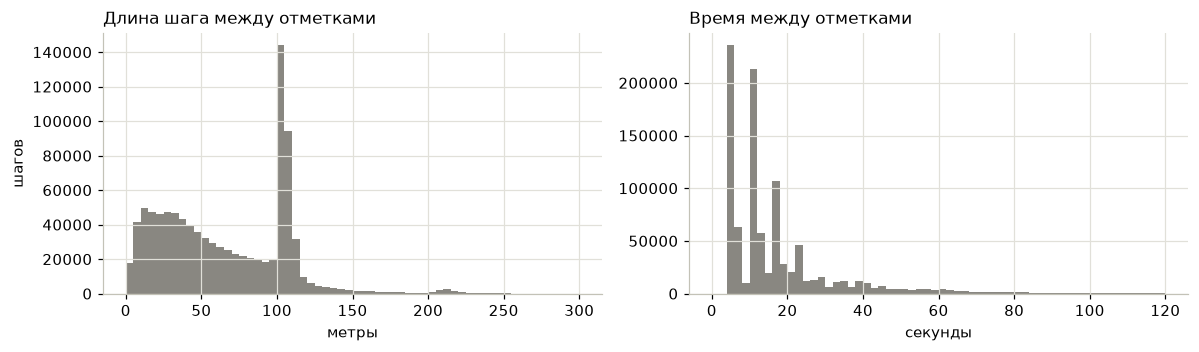

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].hist(steps['length_m'], bins=np.arange(0, 301, 5), color='#898781')
axes[0].set(title='Длина шага между отметками', xlabel='метры', ylabel='шагов')
axes[1].hist(steps['dt_s'], bins=np.arange(0, 121, 2), color='#898781')
axes[1].set(title='Время между отметками', xlabel='секунды')
plt.tight_layout()
plt.show()

Девять шагов из десяти не длиннее ~110 м: бортовое устройство отправляет отметку не реже чем через ~110 м пути, а более длинные шаги — это пропущенные отметки. Поэтому положение автобуса известно с точностью до шага, а момент проезда остановки приходится **вычислять** между двумя отметками. Этим и займёмся.

### 0.7 Проехал ли автобус остановку: скалярное произведение

Для каждого шага $P \to Q$ и остановки $S$:

1. **Проекция.** $u = \dfrac{(S-P)\cdot(Q-P)}{\lVert Q-P\rVert^2}$ показывает, где вдоль шага находится остановка: $u = 0$ — в точке $P$, $u = 1$ — в точке $Q$. Если $0 \le u < 1$, остановка лежит «между» отметками.
2. **Расстояние до линии шага** $d$ должно быть небольшим: не больше 30 м. Иначе автобус ехал по соседней улице.
3. **Направление.** У остановок есть противоположная сторона улицы. В справочнике у каждой остановки записано поле `direction` — код от 1 до 8, направление движения, которое она обслуживает: 1 — на юг, 3 — на запад, 5 — на север, 7 — на восток, чётные коды — диагонали. Переводим код в единичный вектор $\vec e$ и требуем, чтобы $\cos\varphi = \dfrac{\vec v\cdot\vec e}{\lVert\vec v\rVert} \ge \cos 50^\circ$. Иначе это встречный автобус на другой стороне улицы.
4. **Время проезда** — линейная интерполяция: $t = t_P + u\,(t_Q - t_P)$.

Проверяем все шаги сразу, это векторные операции pandas/numpy без циклов по строкам.

In [11]:
# Stop `direction` code (1–8) -> travel heading it serves, degrees clockwise from north
STOP_HEADING = {1: 180, 2: 225, 3: 270, 4: 315, 5: 0, 6: 45, 7: 90, 8: 135}


def stop_passages(steps, stop_id, radius_m=30, max_angle_deg=50):
    """Moments when buses pass the stop while moving in the stop's direction."""
    s = stops_used.loc[stop_id]
    px, py = s['x'] - steps['x0'], s['y'] - steps['y0']                    # vector P -> S
    u = (px * steps['dx'] + py * steps['dy']) / steps['length_m'] ** 2      # projection: dot product / |PQ|^2
    dist = (steps['dx'] * py - steps['dy'] * px).abs() / steps['length_m']  # distance from S to the line PQ
    heading = np.deg2rad(STOP_HEADING[s['direction']])
    ex, ey = np.sin(heading), np.cos(heading)                               # unit vector of the stop direction
    cos_angle = (steps['dx'] * ex + steps['dy'] * ey) / steps['length_m']
    hit = (u >= 0) & (u < 1) & (dist <= radius_m) & (cos_angle >= np.cos(np.deg2rad(max_angle_deg)))
    g = steps[hit]
    return pd.DataFrame({
        'id': g['id'], 'route': g['route'], 'stop_id': stop_id,
        't': g['t0'] + (g['t1'] - g['t0']) * u[hit],   # linear interpolation in time
        'bracket_s': g['dt_s'],                         # time between the two marks = uncertainty of t
        'dist_m': dist[hit],
    })


passages = pd.concat([stop_passages(steps, s) for s in stops_used.index], ignore_index=True)

# A slow bus can be caught on two neighbouring steps: keep one mark per visit, the closest one
passages = passages.sort_values(['id', 'stop_id', 't'])
new_visit = ((passages['id'] != passages['id'].shift()) | (passages['stop_id'] != passages['stop_id'].shift())
             | (passages['t'].diff() > pd.Timedelta(minutes=3)))
passages['visit'] = new_visit.cumsum()
passages = (passages.loc[passages.groupby('visit')['dist_m'].idxmin()]
            .drop(columns='visit').sort_values(['id', 't']).reset_index(drop=True))
print('проездов остановок:', len(passages))
passages.groupby(['stop_id', 'route']).size().unstack(fill_value=0)

проездов остановок: 47872


route,118,169
stop_id,,
31,3147,2591
32,0,2571
114,3136,0
115,3130,0
116,3169,2963
445,3088,0
493,0,2960
494,0,2962
495,0,2977


Каждый маршрут проезжает только свои промежуточные остановки, а A и B — оба. Так и должно быть. Посмотрим на один «пойманный» проезд вблизи остановки A:

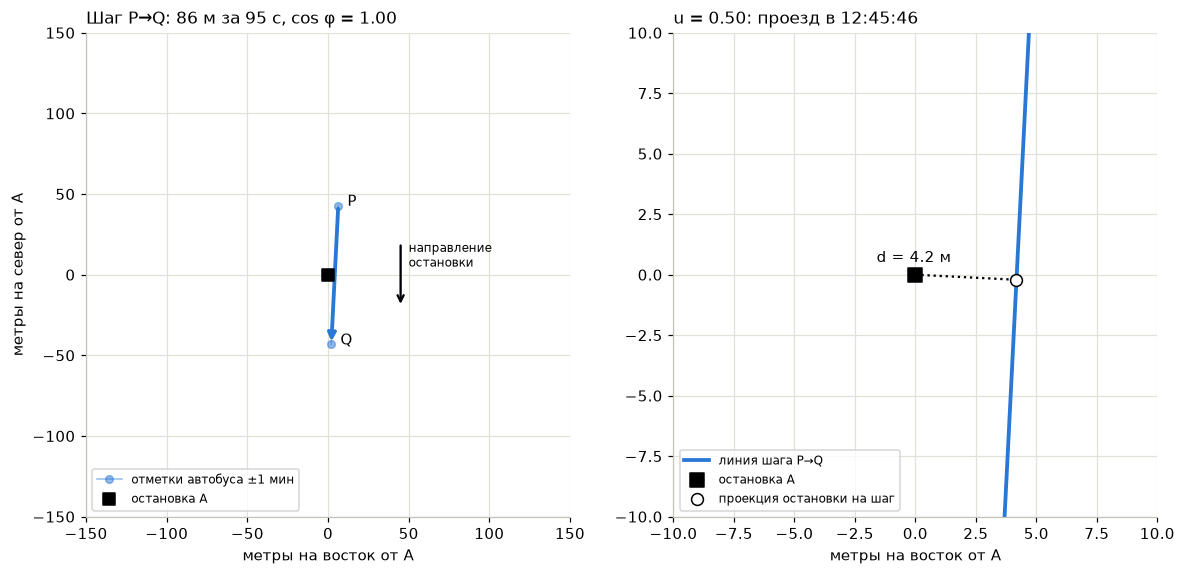

In [12]:
# The same geometry as in stop_passages(), for stop A only, to draw one clear example:
# a long step of route 118 on 16.09 (10–16 h) with stop A near its middle
A = stops_used.loc[STOP_A]
in_day = steps['t0'].between(pd.Timestamp('2026-09-16 10:00', tz=TZ), pd.Timestamp('2026-09-16 16:00', tz=TZ))
cand = steps[in_day & (steps['route'] == 118)].copy()
px, py = A['x'] - cand['x0'], A['y'] - cand['y0']
cand['u'] = (px * cand['dx'] + py * cand['dy']) / cand['length_m'] ** 2
cand['d'] = (cand['dx'] * py - cand['dy'] * px).abs() / cand['length_m']
h = np.deg2rad(STOP_HEADING[A['direction']])
cand['cos'] = (cand['dx'] * np.sin(h) + cand['dy'] * np.cos(h)) / cand['length_m']
hits = cand[cand['u'].between(0.3, 0.7) & (cand['d'] <= 30) & (cand['cos'] >= np.cos(np.deg2rad(50)))]
typical = hits[hits['d'].between(3, 6)]             # a typical distance from the stop to the line
step = (typical if len(typical) else hits).nlargest(1, 'length_m').iloc[0]
t_pass = step['t0'] + (step['t1'] - step['t0']) * step['u']
near = positions[(positions['id'] == step['id'])
                 & positions['t'].between(t_pass - pd.Timedelta(seconds=60), t_pass + pd.Timedelta(seconds=60))]
P = np.array([step['x0'], step['y0']])
Q = P + np.array([step['dx'], step['dy']])
S = np.array([A['x'], A['y']])
proj = P + step['u'] * (Q - P)                     # the point of the step closest to the stop

fig, (ax, zoom) = plt.subplots(1, 2, figsize=(11, 5.2))
# Left: the step among the bus marks
ax.plot(near['x'], near['y'], '-o', color=COLORS[118], ms=5, lw=1, alpha=0.5, label='отметки автобуса ±1 мин')
ax.annotate('', xy=Q, xytext=P, arrowprops=dict(arrowstyle='->', lw=2.5, color=COLORS[118]))
for name, point in [('P', P), ('Q', Q)]:
    ax.annotate(name, point, xytext=(6, 0), textcoords='offset points')
ax.scatter(*S, marker='s', s=70, color='black', zorder=5, label='остановка A')
h = np.deg2rad(STOP_HEADING[A['direction']])
ax.annotate('', xy=(S[0] + 45 + 40 * np.sin(h), S[1] + 20 + 40 * np.cos(h)), xytext=(S[0] + 45, S[1] + 20),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
ax.annotate('направление\nостановки', (S[0] + 50, S[1] + 5), fontsize=8)
ax.set_aspect('equal')
ax.set(xlim=(-150, 150), ylim=(-150, 150), xlabel='метры на восток от A', ylabel='метры на север от A',
       title=f"Шаг P→Q: {step['length_m']:.0f} м за {step['dt_s']:.0f} с, cos φ = {step['cos']:.2f}")
ax.legend(loc='lower left', fontsize=8)

# Right: a close-up of the stop, where the projection and the distance d are visible
direction = (Q - P) / step['length_m']
line = np.array([proj - 12 * direction, proj + 12 * direction])
zoom.plot(line[:, 0], line[:, 1], color=COLORS[118], lw=2.5, label='линия шага P→Q')
zoom.scatter(*S, marker='s', s=90, color='black', zorder=5, label='остановка A')
zoom.scatter(*proj, s=60, color='white', edgecolor='black', zorder=6, label='проекция остановки на шаг')
zoom.plot([S[0], proj[0]], [S[1], proj[1]], ':', color='black')
zoom.annotate(f"d = {step['d']:.1f} м", (S + proj) / 2, xytext=(-10, 10), textcoords='offset points', ha='right')
zoom.set_aspect('equal')
zoom.set(xlim=(S[0] - 10, S[0] + 10), ylim=(S[1] - 10, S[1] + 10), xlabel='метры на восток от A',
         title=f"u = {step['u']:.2f}: проезд в {t_pass.tz_convert(TZ):%H:%M:%S}")
zoom.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

Шаг автобуса смотрит в ту же сторону, что и направление остановки ($\cos\varphi$ близок к 1), проекция остановки попала внутрь шага ($0 \le u < 1$), расстояние до линии шага — несколько метров. Значит, это проезд, и его время лежит между отметками $P$ и $Q$ в доле $u$ от их промежутка.

Расстояние $d$ почти всегда мало: лента «прижимает» отметки к линии маршрута, а остановки стоят у той же линии. Порог в 30 м нужен, чтобы не засчитать автобус с соседней параллельной улицы.

Обратите внимание и на время шага. Если автобус стоял на остановке, между отметками $P$ и $Q$ проходит больше времени, и момент проезда известен менее точно: интерполяция считает, что автобус ехал равномерно. Длительность шага сохраняем в столбце `bracket_s` — это и есть неопределённость момента проезда.

### 0.8 Поездки от A до B

Поездка — это проезд машиной остановки A и **следующий** проезд той же машиной остановки B. Условия:

- B не позже чем через 90 минут после A, и между ними машина не проезжала A ещё раз;
- машина ехала **своим** путём: проехала хотя бы 4 из 6 промежуточных остановок своего маршрута (60%). Это отсекает объезды и редкие рейсы по другой схеме;
- во время поездки лента записывалась без перерывов (`feed_gaps`).

Время в пути: $T = t_B - t_A$, в минутах.

In [13]:
pa = passages[passages['stop_id'] == STOP_A].sort_values(['id', 't']).copy()
pa['next_a'] = pa.groupby('id')['t'].shift(-1)  # the same bus at A the next time
pa = pa.rename(columns={'t': 't_a', 'bracket_s': 'bracket_a_s'})[['id', 'route', 't_a', 'next_a', 'bracket_a_s']]
pb = passages[passages['stop_id'] == STOP_B].rename(columns={'t': 't_b', 'bracket_s': 'bracket_b_s'})
pb = pb[['id', 'route', 't_b', 'bracket_b_s']]

# For every pass of A: the first later pass of B by the same bus, at most 90 min later
trips = pd.merge_asof(pa.sort_values('t_a'), pb.sort_values('t_b'), left_on='t_a', right_on='t_b',
                      by=['id', 'route'], direction='forward', tolerance=pd.Timedelta(minutes=90))
reached = trips['t_b'].notna() & (trips['next_a'].isna() | (trips['t_b'] < trips['next_a']))
print(f'проездов A: {len(trips)}, из них дошли до B: {reached.mean():.1%}')
trips = trips[reached].drop(columns='next_a').sort_values('t_a').reset_index(drop=True)


def passed_between(trips, stop_id):
    """True where the bus passed stop_id after A and before B on that trip."""
    ps = passages.loc[passages['stop_id'] == stop_id, ['id', 't']].rename(columns={'t': 't_s'}).sort_values('t_s')
    m = pd.merge_asof(trips[['id', 't_a', 't_b']].reset_index().sort_values('t_a'), ps,
                      left_on='t_a', right_on='t_s', by='id', direction='forward')
    return pd.Series((m['t_s'] <= m['t_b']).to_numpy(), index=m['index']).sort_index()


trips['path_share'] = np.nan
for route, path in PATH_STOPS.items():
    idx = trips.index[trips['route'] == route]
    trips.loc[idx, 'path_share'] = pd.concat([passed_between(trips.loc[idx], s) for s in path], axis=1).mean(axis=1)
print('доля пройденных промежуточных остановок своего пути:')
display(trips.groupby('route')['path_share'].value_counts().unstack(fill_value=0))

проездов A: 5738, из них дошли до B: 98.3%
доля пройденных промежуточных остановок своего пути:


path_share,0.000000,0.166667,0.500000,0.666667,0.833333,1.000000
route,,,,,,
118,14,2,6,12,43,2994
169,2,0,1,9,90,2465


In [14]:
trips['minutes'] = (trips['t_b'] - trips['t_a']).dt.total_seconds() / 60


def overlaps_gap(start, end):
    """True where the interval [start, end] overlaps a pause in the feed recording."""
    mask = np.zeros(len(start), dtype=bool)
    for gap in feed_gaps.itertuples():
        mask |= ((start < gap.gap_end_utc) & (end > gap.gap_start_utc)).to_numpy()
    return mask


off_path = trips['path_share'] < 0.6
in_gap = overlaps_gap(trips['t_a'], trips['t_b'])
print('не своим путём:', off_path.sum(), '| во время перерыва записи:', in_gap.sum())
trips = trips[~off_path & ~in_gap].reset_index(drop=True)
print('поездок:', len(trips))
trips[['route', 'id', 't_a', 't_b', 'minutes', 'path_share']].head()

не своим путём: 25 | во время перерыва записи: 17
поездок: 5599


,route,id,t_a,t_b,minutes,path_share
0,118,1688,2026-07-25 00:19:52.111570893+00:00,2026-07-25 00:31:44.145523453+00:00,11.867233,1.0
1,169,1903,2026-07-25 00:20:06.171876425+00:00,2026-07-25 00:27:16.759524280+00:00,7.176461,1.0
2,169,1614,2026-07-25 00:29:53.846872895+00:00,2026-07-25 00:37:05.252886541+00:00,7.190100,1.0
3,118,1676,2026-07-25 00:35:04.441689660+00:00,2026-07-25 00:45:00.858996662+00:00,9.940288,1.0
4,169,1230,2026-07-25 00:41:49.301688502+00:00,2026-07-25 00:50:10.094387388+00:00,8.346545,1.0


### 0.9 Календарь и полнота данных

Добавляем местное время отправления от A и признаки дня:

- `day_type` — будний, выходной или праздник. 31 августа — День независимости: это понедельник, но не обычный будний день;
- `season` — «лето» (до 31.08) или «сентябрь»: с 1 сентября начинается учебный год, и движение в городе меняется;
- `window` — окно дня: 07–10, 10–16, 16–20.

Затем проверим, **полны ли данные за каждый день**. Если в какой-то день автобусов в ленте заметно меньше обычного, это не значит, что они не ходили. Возможно, их не записала лента. Правило такое: день полный, если у обоих маршрутов проездов остановки A за 7–20 часов не меньше 75% от медианы для дней того же типа (будни или выходные).

In [15]:
HOLIDAYS = {'2026-08-31': 'День независимости'}
WINDOWS = {'07–10': (7, 10), '10–16': (10, 16), '16–20': (16, 20)}


def add_calendar(df):
    """Local departure time from A and calendar features."""
    local = df['t_a'].dt.tz_convert(TZ)
    df['dep_local'] = local
    df['date'] = local.dt.strftime('%Y-%m-%d')
    df['weekday'] = local.dt.dayofweek                          # 0 = Monday
    df['hour'] = local.dt.hour
    df['dep_hour'] = local.dt.hour + local.dt.minute / 60      # 8.5 = 08:30
    df['day_type'] = np.select([df['date'].isin(list(HOLIDAYS)), df['weekday'] >= 5],
                               ['праздник', 'выходной'], default='будний')
    df['season'] = np.where(df['date'] < '2026-09-01', 'лето', 'сентябрь')
    df['window'] = pd.cut(df['hour'], bins=[7, 10, 16, 20], right=False, labels=list(WINDOWS))
    return df


trips = add_calendar(trips)

# Every bus that passed A, whether or not the trip to B was recovered (needed in part 2)
departures = passages.loc[passages['stop_id'] == STOP_A, ['id', 'route', 't', 'bracket_s']]
departures = departures.rename(columns={'t': 't_a', 'bracket_s': 'bracket_a_s'})
departures = departures.merge(trips[['id', 't_a', 't_b', 'minutes']], on=['id', 't_a'], how='left')
departures['reached_b'] = departures['t_b'].notna()
departures = add_calendar(departures).sort_values('t_a').reset_index(drop=True)

# Completeness of every day: buses passing A between 7 and 20 h
all_dates = pd.date_range('2026-07-25', '2026-09-22', freq='D').strftime('%Y-%m-%d')
counts = (departures[departures['hour'].between(7, 19)].groupby(['date', 'route']).size()
          .unstack(fill_value=0).reindex(all_dates, fill_value=0))
day_info = pd.DataFrame({'buses_118': counts[118], 'buses_169': counts[169]})
day_info.index.name = 'date'
day_info['weekday'] = pd.to_datetime(day_info.index).dayofweek
kind = np.where(day_info['weekday'] >= 5, 'выходной', 'будний')
day_info['day_type'] = np.where(day_info.index.isin(list(HOLIDAYS)), 'праздник', kind)
for r in [118, 169]:
    typical = day_info.groupby(kind)[f'buses_{r}'].transform('median')
    day_info[f'share_{r}'] = (day_info[f'buses_{r}'] / typical).round(2)
day_info['day_ok'] = (day_info[['share_118', 'share_169']].min(axis=1) >= 0.75) & (day_info['day_type'] != 'праздник')

trips['day_ok'] = trips['date'].map(day_info['day_ok'])
departures['day_ok'] = departures['date'].map(day_info['day_ok'])
print('неполные дни и праздник:')
display(day_info[~day_info['day_ok']])

неполные дни и праздник:

,buses_118,buses_169,weekday,day_type,share_118,share_169,day_ok
date,,,,,,,
2026-08-01,22,19,5,выходной,0.47,0.48,False
2026-08-07,38,42,4,будний,0.73,1.06,False
2026-08-20,27,23,3,будний,0.52,0.58,False
2026-08-21,7,5,4,будний,0.13,0.13,False
2026-08-22,24,22,5,выходной,0.51,0.56,False
2026-08-30,47,17,6,выходной,1.00,0.43,False
2026-08-31,0,6,0,праздник,0.00,0.15,False
2026-09-01,7,4,1,будний,0.13,0.10,False


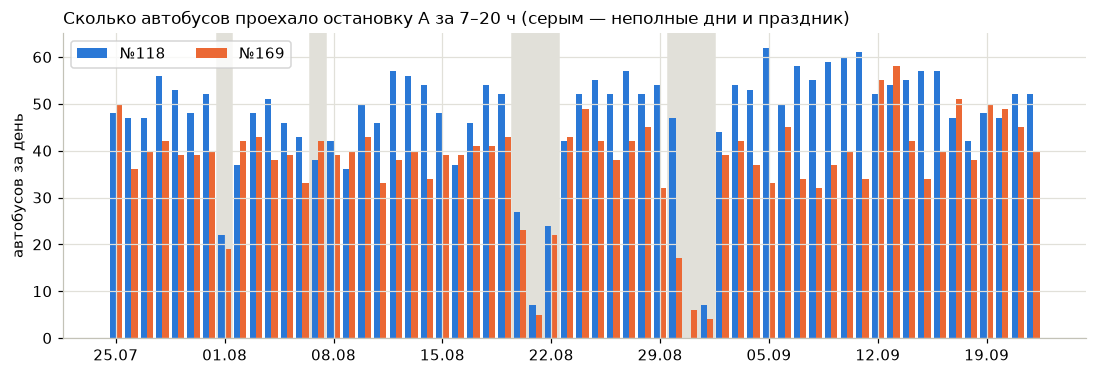

In [16]:
fig, ax = plt.subplots(figsize=(12, 3.6))
x = np.arange(len(day_info))
for offset, r in [(-0.2, 118), (0.2, 169)]:
    ax.bar(x + offset, day_info[f'buses_{r}'], width=0.4, color=COLORS[r], label=f'№{r}')
for i in np.flatnonzero(~day_info['day_ok'].to_numpy()):
    ax.axvspan(i - 0.5, i + 0.5, color='#e1e0d9', zorder=0)
ax.set_xticks(x[::7], [d[8:10] + '.' + d[5:7] for d in day_info.index[::7]])
ax.set(title='Сколько автобусов проехало остановку A за 7–20 ч (серым — неполные дни и праздник)',
       ylabel='автобусов за день')
ax.legend(loc='upper left', ncols=2)
plt.show()

Главные провалы — перерывы записи ленты: 1 августа и 20–22 августа (перерыв и восстановление). 31 августа — праздник, а 1 сентября лента записала лишь около десятой части обычного числа автобусов. Ещё в два дня, 7 и 30 августа, заметно меньше обычного было автобусов одного из маршрутов. Настоящий это перерыв в движении или пропуск записи, по этим данным не понять, поэтому такие дни тоже откладываем. **В заданиях используем только полные дни** (`day_ok`).

### 0.10 Первый взгляд на данные

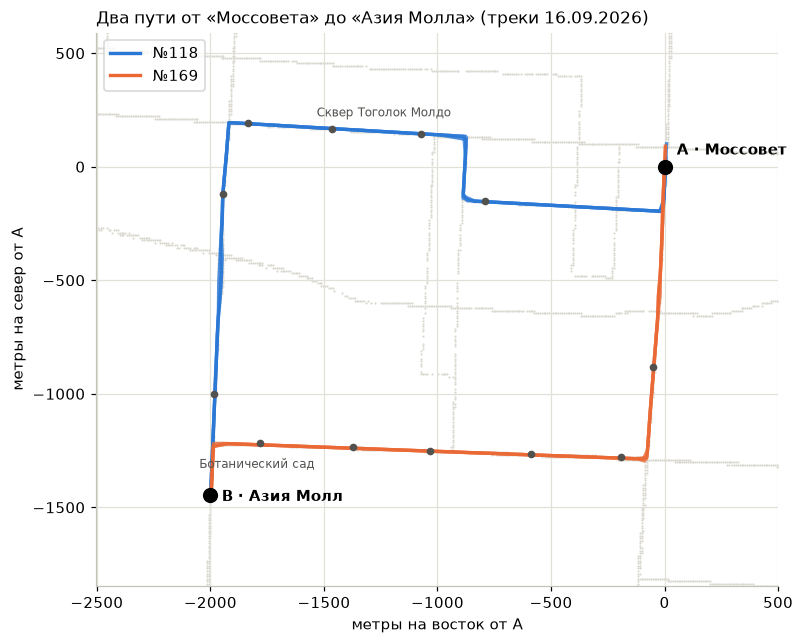

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
sx, sy = to_xy(streets['lat'], streets['lng'])
ax.scatter(sx, sy, s=2, color='#d9d7cf', linewidths=0)  # streets used by transit on one weekday

# Three typical trips of each route on one weekday, drawn from the cleaned marks
sample = trips[(trips['date'] == '2026-09-16') & trips['hour'].between(10, 15)].copy()
sample['gap_to_median'] = (sample['minutes'] - sample.groupby('route')['minutes'].transform('median')).abs()
for _, trip in sample.sort_values('gap_to_median').groupby('route').head(3).iterrows():
    track = positions[(positions['id'] == trip['id'])
                      & positions['t'].between(trip['t_a'] - pd.Timedelta(seconds=30), trip['t_b'] + pd.Timedelta(seconds=30))]
    ax.plot(track['x'], track['y'], color=COLORS[trip['route']], lw=2.2, alpha=0.8)
for r in [118, 169]:
    ax.plot([], [], color=COLORS[r], lw=2.2, label=f'№{r}')

on_path = stops_used[stops_used['role'].str.startswith('путь')]
ax.scatter(on_path['x'], on_path['y'], s=16, color='#52514e', zorder=3)
for sid, label, offset in [(STOP_A, 'A · Моссовет', (8, 8)), (STOP_B, 'B · Азия Молл', (8, -4)),
                           (1353, 'Сквер Тоголок Молдо', (-10, 8)), (497, 'Ботанический сад', (-40, -16))]:
    s = stops_used.loc[sid]
    big = sid in (STOP_A, STOP_B)
    if big:
        ax.scatter(s['x'], s['y'], s=80, color='black', zorder=4)
    ax.annotate(label, (s['x'], s['y']), xytext=offset, textcoords='offset points',
                fontsize=10 if big else 8, weight='bold' if big else 'normal', color='black' if big else '#52514e')
ax.set_aspect('equal')
ax.set(xlim=(stops_used['x'].min() - 500, stops_used['x'].max() + 500),
       ylim=(stops_used['y'].min() - 400, stops_used['y'].max() + 400),
       xlabel='метры на восток от A', ylabel='метры на север от A',
       title='Два пути от «Моссовета» до «Азия Молла» (треки 16.09.2026)')
ax.legend(loc='upper left')
plt.show()

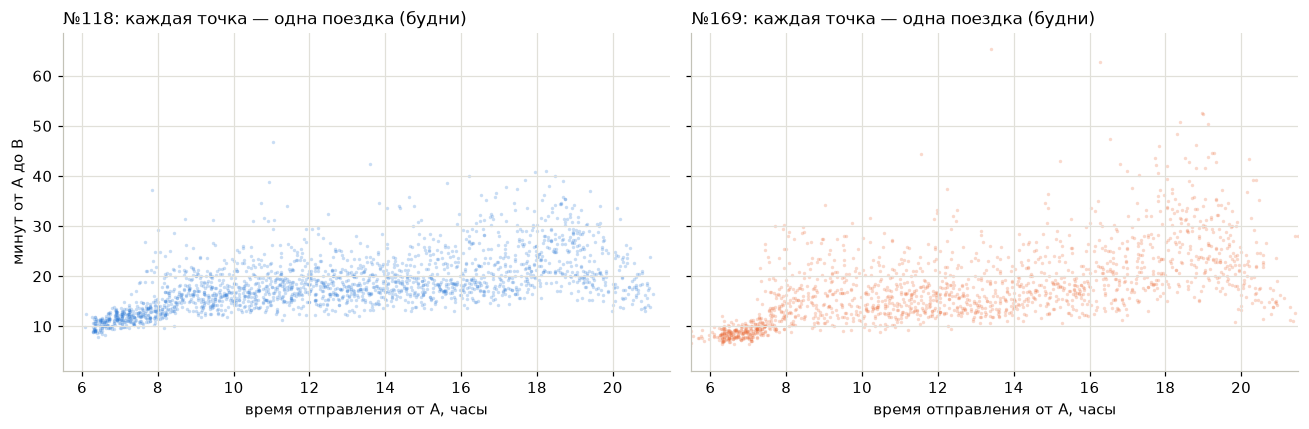

In [18]:
weekdays = trips[(trips['day_type'] == 'будний') & trips['day_ok']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, r in zip(axes, [118, 169]):
    g = weekdays[weekdays['route'] == r]
    ax.scatter(g['dep_hour'], g['minutes'], s=5, alpha=0.25, color=COLORS[r], linewidths=0)
    ax.set(title=f'№{r}: каждая точка — одна поездка (будни)', xlabel='время отправления от A, часы', xlim=(5.5, 21.5))
axes[0].set_ylabel('минут от A до B')
plt.tight_layout()
plt.show()

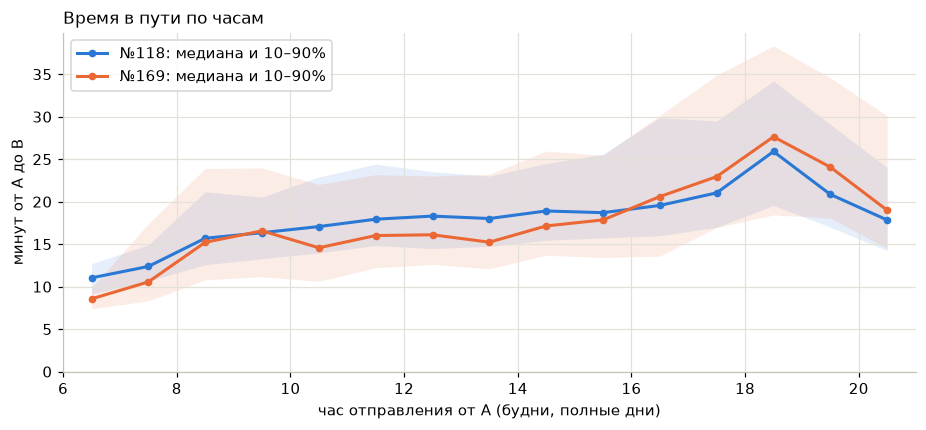

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
for r in [118, 169]:
    by_hour = (weekdays[weekdays['route'] == r].groupby('hour')['minutes']
               .agg(n='size', median='median', low=lambda s: s.quantile(0.1), high=lambda s: s.quantile(0.9)))
    by_hour = by_hour[by_hour['n'] >= 20]
    ax.fill_between(by_hour.index + 0.5, by_hour['low'], by_hour['high'], color=COLORS[r], alpha=0.12, linewidth=0)
    ax.plot(by_hour.index + 0.5, by_hour['median'], '-o', color=COLORS[r], lw=2, ms=4, label=f'№{r}: медиана и 10–90%')
ax.set(xlim=(6, 21), ylim=(0, None), xlabel='час отправления от A (будни, полные дни)', ylabel='минут от A до B',
       title='Время в пути по часам')
ax.legend(loc='upper left')
plt.show()

Медианы двух маршрутов близки, отличие — пара минут. Зато полосы разброса отличаются, особенно вечером. Для вопроса «успею ли» важна не середина, а весь разброс. Этим и займётся часть 1.

### 0.11 Итог: что у нас есть

**`trips`** — одна строка = одна поездка автобуса от A («Моссовет») до B («Азия Молл»):

| Столбец | Что это |
|---|---|
| `route` | маршрут: 118 или 169 |
| `id` | номер машины в ленте |
| `t_a`, `t_b` | проезд остановок A и B (UTC) |
| `minutes` | **время в пути** $T$, минуты |
| `dep_local` | время отправления от A, местное |
| `date`, `weekday`, `hour`, `dep_hour` | дата, день недели (0 = понедельник), час и час с долями |
| `day_type` | будний / выходной / праздник |
| `season` | лето (до 31.08) / сентябрь |
| `window` | окно дня: 07–10, 10–16, 16–20 (или пусто) |
| `day_ok` | день с полными данными |
| `path_share` | доля пройденных промежуточных остановок своего пути |
| `bracket_a_s`, `bracket_b_s` | время между отметками вокруг A и B, с (неопределённость момента проезда) |

**`departures`** — одна строка = один автобус, проехавший остановку A (для части 2): те же календарные столбцы и `t_a`, плюс `reached_b` (восстановлена ли поездка до B), `t_b` и `minutes` (пусто, если не восстановлена).

**`day_info`** — одна строка = один день: число автобусов каждого маршрута у A за 7–20 ч, доля от обычного, `day_ok`.

**`stops_used`** — остановки A, B и промежуточные. **`feed_gaps`** — перерывы записи ленты. **`positions`**, **`steps`**, **`passages`** — промежуточные таблицы части 0.

In [20]:
print('поездок:', trips.groupby('route').size().to_dict(),
      '| из них в будни с полными данными:', trips[(trips['day_type'] == 'будний') & trips['day_ok']].groupby('route').size().to_dict())
print('автобусов у A:', departures.groupby('route').size().to_dict(), '| полных будних дней:',
      int((day_info['day_ok'] & (day_info['day_type'] == 'будний')).sum()))

поездок: {118: 3043, 169: 2556} | из них в будни с полными данными: {118: 2101, 169: 1682}
автобусов у A: {118: 3147, 169: 2591} | полных будних дней: 37


# Часть 1. Сравниваем маршруты
## 1. Время суток имеет значение

Сначала посмотрим на среднее время поездки утром, днём и вечером.
**Предположите:** может ли №169 быть быстрее днём, но медленнее вечером?

Код готов: запустите его и прочитайте график.

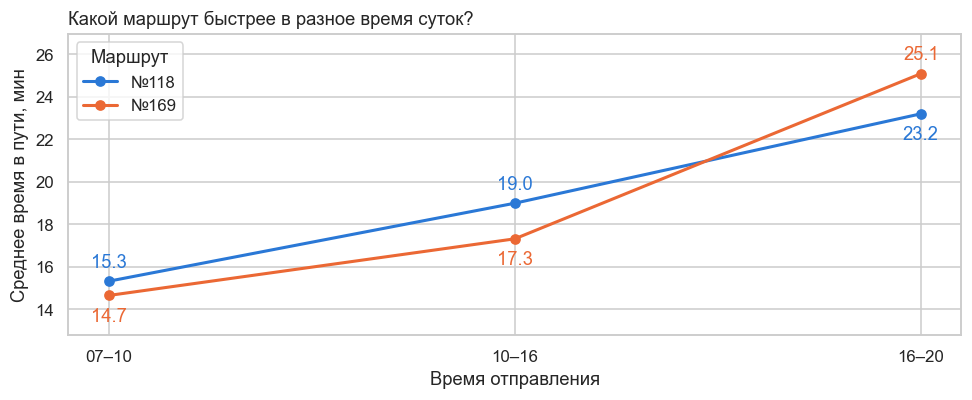

In [21]:
# Provided: compare the three departure windows.
import seaborn as sns

sns.set_theme(style='whitegrid')
wd = trips.loc[(trips['day_type'] == 'будний') & trips['day_ok'] & trips['window'].notna()].copy()
by_window = wd.groupby(['window', 'route'], observed=True)['minutes'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 3.8))
for route in [118, 169]:
    ax.plot(by_window.index.astype(str), by_window[route], marker='o', lw=2,
            color=COLORS[route], label=f'№{route}')
    for x, value in enumerate(by_window[route]):
        other_route = 169 if route == 118 else 118
        offset = 9 if value >= by_window[other_route].iloc[x] else -17
        ax.annotate(f'{value:.1f}', (x, value), xytext=(0, offset),
                    textcoords='offset points', ha='center', color=COLORS[route])
ax.set(xlabel='Время отправления', ylabel='Среднее время в пути, мин',
       title='Какой маршрут быстрее в разное время суток?')
ax.legend(title='Маршрут')
ax.margins(y=0.18)
plt.tight_layout()
plt.show()

**Для преподавателя — вывод.** Утром средние близки: 15,3 минуты у №118 и 14,7 у №169.
Днём №169 быстрее: 17,3 против 19,0 минуты. Вечером быстрее №118: 23,2 против 25,1.
Поэтому дальше сравниваем **только утро, с 07:00 до 10:00**. Одно среднее за весь день скрыло бы эту картину.

## 2. Посчитаем разницу за каждый день

В один день дороги свободны, в другой — пробки. Поэтому сравним маршруты **в одну дату**:
сначала найдём среднее время каждого маршрута за утро, затем вычтем одно из другого.

Условный пример: №118 ехал в среднем 18 минут, №169 — 16. Разница «№169 минус №118» равна −2 минутам.
Значит, в этот день №169 был быстрее на 2 минуты.

> **Минус — быстрее №169. Плюс — быстрее №118.** Этот порядок вычитания сохраняем до конца работы.

После подготовки получится одна разница на каждый день. Найдём среднее этих разниц:

$$\overline d=\frac{1}{D}\sum_{j=1}^{D}d_j.$$

**Где:** $d_j$ — разница средних времён в день $j$, в минутах; $D$ — число дней;
$\overline d$ — средняя разница по всем этим дням; $\sum$ означает сложение.

Каждый день учитываем один раз, даже если число поездок в разные дни неодинаково.
Для дальнейших расчётов считаем дни независимыми наблюдениями при похожих условиях.
Если соседние дни тесно связаны или условия резко менялись, оценка точности может быть неверной.

**Готовый код** ниже создаёт таблицу и массив `d` с дневными разницами.

In [22]:
# Provided: one row per date, with both route means.
morning = wd.loc[wd['window'] == '07–10']
daily = morning.groupby(['date', 'route'])['minutes'].mean().unstack().dropna(subset=[118, 169])
daily['diff'] = daily[169] - daily[118]
d = daily['diff'].to_numpy()
D = len(d)
if D < 2:
    raise ValueError('Нужны данные хотя бы за два дня с обоими маршрутами.')

print('Дней для сравнения:', D)
print(daily.head().rename(columns={118: '№118, мин', 169: '№169, мин',
                                   'diff': 'Разница, мин'}).round(2).to_string())

Дней для сравнения: 37
route       №118, мин  №169, мин  Разница, мин
date                                          
2026-07-27      15.95      12.98         -2.98
2026-07-28      16.00      13.64         -2.36
2026-07-29      15.93      13.71         -2.22
2026-07-30      17.19      14.17         -3.02
2026-07-31      16.62      17.99          1.38


**Задание A.** Найдите среднюю разницу. Для массива `d` среднее вычисляет метод `.mean()`.
По знаку результата определите, какой маршрут в среднем быстрее.

In [23]:
# Solution A.
observed = d.mean()
print(f'Средняя разница №169 − №118: {observed:.2f} мин')

Средняя разница №169 − №118: -0.58 мин


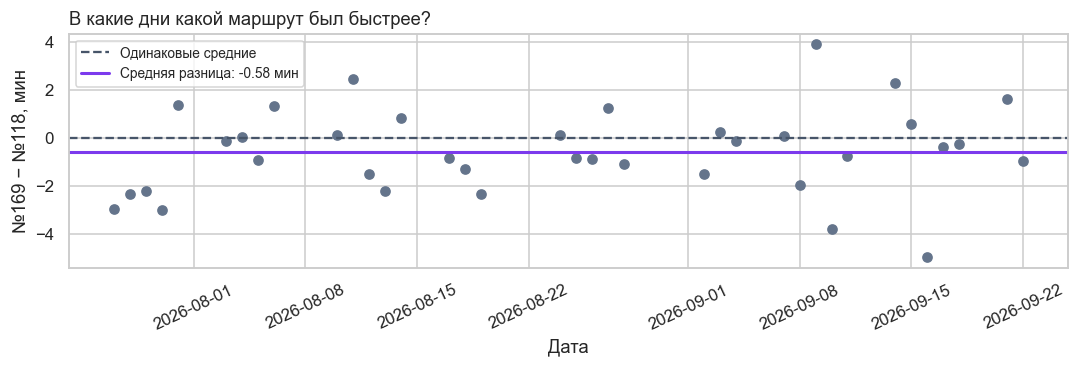

In [24]:
# Provided: each point is one morning.
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(pd.to_datetime(daily.index), d, color='#64748b')
ax.axhline(0, color='#475569', ls='--', label='Одинаковые средние')
ax.axhline(observed, color='#7c3aed', lw=2, label=f'Средняя разница: {observed:.2f} мин')
ax.set(xlabel='Дата', ylabel='№169 − №118, мин', title='В какие дни какой маршрут был быстрее?')
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Для преподавателя — вывод.** Получили **37 дневных сравнений**. Средняя разница — **−0,58 минуты**:
утром №169 быстрее примерно на 35 секунд. Но на графике есть точки с обеих сторон нуля.
Значит, №169 быстрее в среднем, а не каждое утро.

## 3. Что получится, если случайно поменять названия маршрутов?

Наблюдаемую разницу мы уже знаем. Теперь проведём опыт: для каждого дня случайно решим,
оставить названия маршрутов или поменять их местами. Шансы двух вариантов одинаковы.

| Условный пример | №118 | №169 | Разница №169 − №118 |
|---|---:|---:|---:|
| До обмена | 18 мин | 16 мин | −2 мин |
| После обмена названий | 16 мин | 18 мин | +2 мин |

При обмене меняется только знак разницы. Сделаем такой выбор независимо для каждого дня,
затем снова найдём среднее. Повторим опыт много раз.

**Перестановочный метод (permutation method)** сравнивает наблюдаемый результат с результатами
случайных перестановок меток данных. У нас метки — номера маршрутов; меняем их только внутри одного дня.
Это модель, в которой разницы +2 и −2 минуты одинаково возможны, как и +3 и −3.
Её результат относится именно к такому предположению.

**Сначала одно повторение.** Умножение на −1 меняет знак числа, на +1 — оставляет его прежним.
В таблице ниже показаны первые пять дней; среднее считаем по всем 37.

In [25]:
# Provided: inspect one permutation before writing the loop.
rng_example = np.random.default_rng(8100)
one_permutation = d * rng_example.choice([-1, 1], size=D)
example = pd.DataFrame({'До обменов': d, 'После обменов': one_permutation}, index=daily.index)
print(example.head().round(2).to_string())
print(f'Средняя разница после этих обменов: {one_permutation.mean():.2f} мин')

            До обменов  После обменов
date                                 
2026-07-27       -2.98          -2.98
2026-07-28       -2.36           2.36
2026-07-29       -2.22          -2.22
2026-07-30       -3.02          -3.02
2026-07-31        1.38          -1.38
Средняя разница после этих обменов: -0.18 мин


**Задание B.** Повторите опыт 9999 раз. Каждый раз сохраните одно среднее.

**Памятка:** `rng.choice([-1, 1], size=D)` выбирает по одному знаку для каждого дня.
`d * signs` применяет эти знаки к разницам; `.append(...)` добавляет результат в список.

После цикла сравним полученные средние с настоящей разницей.
Нас интересует разница **такой же величины или больше — в любую сторону**.
Например, при наблюдении −0,58 подходят и −0,8, и +0,8, но не +0,2.

In [26]:
rng_perm = np.random.default_rng(8103)
B = 9999
perm_means = []

# Solution B.
for _ in range(B):
    signs = rng_perm.choice([-1, 1], size=D)
    perm_means.append((d * signs).mean())

perm_means = np.array(perm_means)

Такая же разница или больше: 605 из 9999 повторений (6.05%).


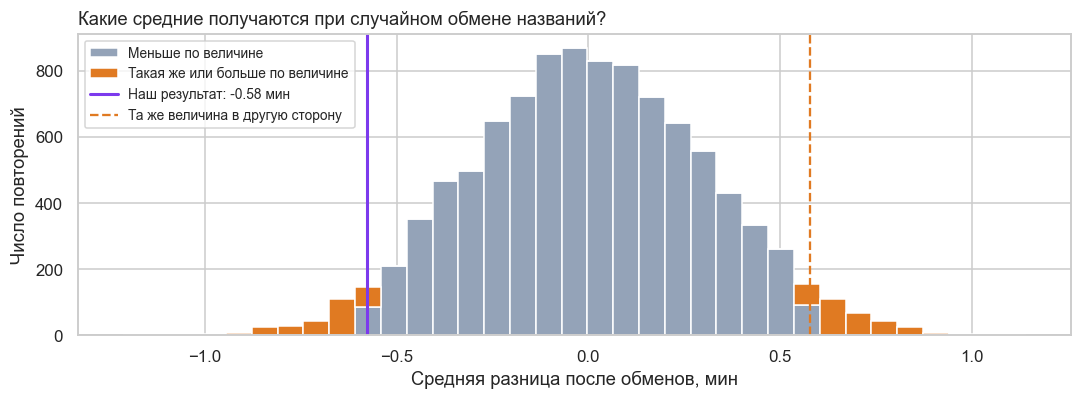

In [27]:
# Provided: np.abs measures the distance from zero.
extreme = np.abs(perm_means) >= abs(observed) - 1e-12
print(f'Такая же разница или больше: {extreme.sum()} из {B} повторений ({extreme.mean():.2%}).')

fig, ax = plt.subplots(figsize=(10, 3.8))
edges = np.histogram_bin_edges(perm_means, bins=35)
ax.hist([perm_means[~extreme], perm_means[extreme]], bins=edges, stacked=True,
        color=['#94a3b8', '#e07a22'], label=['Меньше по величине', 'Такая же или больше по величине'])
ax.axvline(observed, color='#7c3aed', lw=2, label=f'Наш результат: {observed:.2f} мин')
ax.axvline(-observed, color='#e07a22', ls='--', label='Та же величина в другую сторону')
ax.set(xlabel='Средняя разница после обменов, мин', ylabel='Число повторений',
       title='Какие средние получаются при случайном обмене названий?')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Для преподавателя — вывод.** В **605 из 9999 повторений — около 6% —** получилась разница такой же величины или больше.
Это частота результата в нашем опыте со случайным обменом названий.
Она **не означает «вероятность случайности различия — 6%»**.

## 4. Бутстрап: насколько может меняться среднее?

По другим дням мы могли бы получить другую среднюю разницу. Новых данных пока нет.
Попробуем использовать уже записанные дни для оценки этого разброса.

**Бутстрап (bootstrap)** — многократный случайный выбор наблюдений из исходной выборки
**с возвращением**, с сохранением её размера, и пересчёт нужного показателя.
У нас исходная выборка — 37 дневных разниц, показатель — их среднее.

«С возвращением» означает: выбранный день можно выбрать ещё раз.
В каждом новом наборе будет 37 записей; некоторые дни повторятся, другие не попадут.

**Одна бутстрап-выборка — готовый пример.** Выбираем номера дней, чтобы были видны повторы.
`replace=True` разрешает повторный выбор, `size=D` задаёт число записей.

In [28]:
# Provided: inspect one bootstrap sample.
rng_example = np.random.default_rng(8104)
indices = rng_example.choice(np.arange(D), size=D, replace=True)
print('Номера выбранных дней:', indices + 1)
print(f'Всего записей: {D}; разных дней: {len(np.unique(indices))}.')
print(f'Среднее этой бутстрап-выборки: {d[indices].mean():.2f} мин')

Номера выбранных дней:

 [24  2 37 35 13  6 23 16 25 23 16 24 36  6 29  1  4  9 30 10 23 14 16  2
 20 14 23 29 34 34 23 34 18  8 36 23 25]
Всего записей: 37; разных дней: 21.
Среднее этой бутстрап-выборки: -0.87 мин


**Задание C.** Получите 9999 бутстрап-выборок и сохраните среднее каждой.
В цикле можно сразу выбирать значения из `d`, без номеров дней.

**Памятка:** `rng.choice(d, size=D, replace=True)` создаёт одну повторную выборку.
Метод `.mean()` находит её среднее.

`D` — число наблюдавшихся дней, `B` — число повторных расчётов.
Увеличение `B` не добавляет новых дней.

In [29]:
rng_boot = np.random.default_rng(8105)
boot_means = []

# Solution C.
for _ in range(B):
    boot_sample = rng_boot.choice(d, size=D, replace=True)
    boot_means.append(boot_sample.mean())

boot_means = np.array(boot_means)
print(f'Среднее бутстрап-средних: {boot_means.mean():.2f} мин')

Среднее бутстрап-средних: -0.58 мин


**Для преподавателя — вывод.** Бутстрап-средние расположены около **−0,58 минуты**, то есть около результата исходной выборки.
В отдельных повторениях ответы различаются. По их разбросу оценим точность нашего среднего.
При перестановках мы случайно меняли направление различий, поэтому средние собирались около нуля.

## 5. Вместо одного числа — доверительный интервал

Наша оценка — минус 0,58 минуты. Покажем её точность с помощью интервала.

**Доверительный интервал (confidence interval)** — интервал по выборке для оценки неизвестного
параметра, построенный методом с заданным уровнем доверия.
Здесь параметр — средняя разница между маршрутами во всех будних днях с похожими условиями.

Смысл **95%-го уровня доверия**: при многократном сборе новых выборок около 95 из 100 интервалов
содержали бы истинную среднюю разницу, если условия метода выполнены.
Наши способы приближённые, поэтому фактическая доля может отличаться от 95%.

Построим два интервала из занятия 8.

**По формуле:** от среднего отступаем в обе стороны примерно на две стандартные ошибки.
Стандартная ошибка среднего — стандартное отклонение средних, которые получались бы при повторном
сборе выборок того же размера из одной генеральной совокупности.
Здесь оцениваем её как $s_d/\sqrt D$.

$$I_{\mathrm{normal}}=\left[\overline d-1{,}96\frac{s_d}{\sqrt D},\;
\overline d+1{,}96\frac{s_d}{\sqrt D}\right].$$

**Где:** $I_{\mathrm{normal}}$ — интервал по нормальному приближению;
$\overline d$ — средняя дневная разница; $s_d$ — выборочное стандартное отклонение дневных разниц;
$D$ — число дней; $1{,}96$ — коэффициент для центральных 95% стандартного нормального распределения.
Формулу используем как приближение, когда распределение среднего близко к нормальному.

**По бутстрапу:** берём границы центральных 95% бутстрап-средних.
Такой интервал называют **процентильным (percentile interval)**.

$$I_{\mathrm{boot}}=[q^*_{0.025},\;q^*_{0.975}].$$

**Где:** $I_{\mathrm{boot}}$ — бутстрап-интервал;
$q^*_{0.025}$ и $q^*_{0.975}$ — квантили 2,5% и 97,5% бутстрап-средних;
звёздочка отмечает значения, полученные бутстрапом.

**Задание D.** Рассчитайте оба интервала.
`d.std(ddof=1)` даёт выборочное стандартное отклонение дневных разниц.
`np.quantile(boot_means, [0.025, 0.975])` даёт границы бутстрап-интервала.

> Границы строим для **средней разницы**. Это не диапазон времени отдельной поездки.

In [30]:
# Solution D.
se = d.std(ddof=1) / np.sqrt(D)
normal_ci = np.array([observed - 1.96 * se, observed + 1.96 * se])
boot_ci = np.quantile(boot_means, [0.025, 0.975])

print(f'Стандартная ошибка среднего: {se:.3f} мин')
print('Интервал по формуле:', normal_ci.round(3))
print('Бутстрап-интервал:  ', boot_ci.round(3))

Стандартная ошибка среднего: 0.297 мин
Интервал по формуле: [-1.16   0.003]
Бутстрап-интервал:   [-1.143 -0.008]


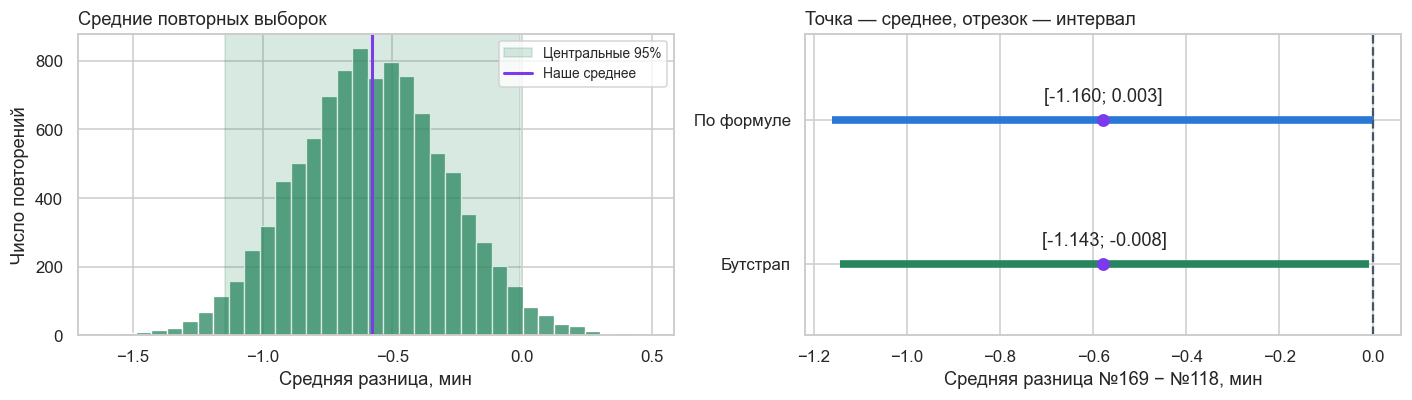

In [31]:
# Provided: show bootstrap means and both intervals.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.histplot(boot_means, bins=35, color='#27865d', ax=axes[0])
axes[0].axvspan(*boot_ci, color='#27865d', alpha=0.18, label='Центральные 95%')
axes[0].axvline(observed, color='#7c3aed', lw=2, label='Наше среднее')
axes[0].set(title='Средние повторных выборок', xlabel='Средняя разница, мин', ylabel='Число повторений')
axes[0].legend(fontsize=9)

for y, ci, label, color in [(1, normal_ci, 'По формуле', '#2a78d6'), (0, boot_ci, 'Бутстрап', '#27865d')]:
    axes[1].hlines(y, *ci, color=color, lw=5)
    axes[1].scatter(observed, y, color='#7c3aed', s=55, zorder=3)
    axes[1].annotate(f'[{ci[0]:.3f}; {ci[1]:.3f}]', (ci.mean(), y), xytext=(0, 12),
                     textcoords='offset points', ha='center')
axes[1].axvline(0, color='#475569', ls='--')
axes[1].set_yticks([0, 1], ['Бутстрап', 'По формуле'])
axes[1].set(title='Точка — среднее, отрезок — интервал', xlabel='Средняя разница №169 − №118, мин', ylim=(-0.5, 1.6))
plt.tight_layout()
plt.show()

**Для преподавателя — вывод.** По формуле получили примерно **[−1,160; +0,003] минуты**, по бутстрапу — **[−1,143; −0,008]**.
Оба интервала показывают: среднее преимущество №169 может быть совсем небольшим или доходить примерно до минуты.
Одна граница чуть выше нуля, другая чуть ниже — это разные приближённые методы.
Разница в последних цифрах не даёт оснований для категоричного выбора маршрута.

## 6. Что ответим пассажиру?

**Перестановки:** как часто такая большая разница появляется при случайном обмене названий?

**Бутстрап:** насколько может меняться наша оценка средней разницы?

**Ваш вывод — 3–4 предложения:** какой маршрут быстрее утром в наших данных, на сколько,
насколько точна оценка и почему нельзя обещать такой выигрыш в каждой поездке?

**Для преподавателя — вывод.** По данным 37 будних дней с 07:00 до 10:00 №169 ехал в среднем примерно на **35 секунд быстрее**.
Преимущество небольшое, а интервалы заканчиваются почти у нуля, поэтому уверенно обещать выигрыш нельзя.
В отдельные дни быстрее был №118. Вывод касается времени в пути: ожидание автобуса мы не учитывали.

**Источники**

- [Предыдущий практикум: подготовка данных](practicum_mossovet_asia_mall_KEY.ipynb).
- [Занятие 8: доверительные интервалы и бутстрап](../math_for_ds/08_stat_ci_bootstrap.ipynb).
- [Tim Hesterberg: введение в перестановки и бутстрап, раздел 2](https://arxiv.org/html/1411.5279).
- SciPy: [перестановки внутри пар](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.permutation_test.html),
  [бутстрап и процентильный интервал](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html).